# Trabalho Prático 2 — Introdução a Banco de Dados
## Banco de Preços em Saúde (BPS)
**Fonte:** https://dados.gov.br/dados/conjuntos-dados/banco-de-preco-em-saude-bps

## 2. Membros do Grupo

| Nome | Matrícula |
|------|-----------|
| Andrei Gustavo Sartão | 2024008717 |
| Júlia Luíza Costa de Toledo | 2024008431 |
| Rodrigo Anastácio Pena e Silva | 2024008520 |
| Victor Coutinho Altafim | 2024008385 |

## 3. Descrição e Processamento dos Dados

O conjunto de dados utilizado é o **Banco de Preços em Saúde (BPS)**,
disponibilizado pelo Ministério da Saúde no portal dados.gov.br.
O BPS registra compras públicas de produtos médico-hospitalares realizadas
por instituições de saúde de todo o Brasil.

Os dados foram obtidos em **7 arquivos CSV** totalizando **342.716 linhas**
e **25 colunas** na forma não-normalizada. A partir disso, o esquema foi
normalizado até a **3ª Forma Normal (3FN)**, resultando em 6 tabelas
implementadas em SQLite.

| Tabela | Instâncias |
|--------|------------|
| Instituicao | 831 |
| Fabricante | 2.290 |
| Produto | 12.994 |
| Fornecedor | 3.502 |
| Compra | 1.887 |
| Item_Compra | 334.530 |
| **Total** | **356.034** |

In [14]:
import pandas as pd
import glob
import os
import sqlite3

# Mapeia todos os arquivos .csv dentro da pasta 'data'
# Assumindo que o seu notebook está na mesma pasta raiz que a pasta 'data'
caminho_arquivos = glob.glob(os.path.join('data', '*.csv'))

# Cria uma lista vazia para armazenar os DataFrames individuais
lista_dfs = []

# Loop para ler cada arquivo e adicioná-lo à lista
for arquivo in caminho_arquivos:
    # Lendo o CSV. Ajuste o 'sep' e 'encoding' conforme necessário para o seu dado específico
    df_temp = pd.read_csv(arquivo, sep=';', encoding='utf-8') 
    lista_dfs.append(df_temp)

# Concatena (empilha) todos os DataFrames da lista verticalmente
df_unificado = pd.concat(lista_dfs, ignore_index=True)

# Coleta as dimensões do DataFrame final
total_linhas, total_colunas = df_unificado.shape

print(f"Total de arquivos lidos: {len(caminho_arquivos)}")
print(f"Total de linhas (instâncias na UNF): {total_linhas}")
print(f"Total de colunas: {total_colunas}")

# 1. Conectar ao SQLite (cria o arquivo do banco no seu computador)
conn = sqlite3.connect('trabalho_pratico_2.db')

# 2. Enviar o DataFrame unificado inteiro para o banco como uma "Tabela Raw/Bruta"
# O if_exists='replace' garante que você pode rodar a célula várias vezes sem erro
df_unificado.to_sql('dados_brutos', conn, if_exists='replace', index=False)

Total de arquivos lidos: 7
Total de linhas (instâncias na UNF): 342716
Total de colunas: 25


342716

In [15]:
cursor = conn.cursor()

# 1. Otimização recomendada: Desativar temporariamente checagem de FK e ativar modo síncrono off
cursor.execute("PRAGMA foreign_keys = OFF;")
cursor.execute("PRAGMA synchronous = OFF;")
cursor.execute("PRAGMA journal_mode = MEMORY;")

print("Iniciando a criação do esquema e migração dos dados...")

# ==========================================
# DDL - CRIAÇÃO DAS TABELAS (3FN)
# ==========================================

# Tabela 1: Instituição
cursor.execute('''
CREATE TABLE IF NOT EXISTS Instituicao (
    cnpj_instituicao TEXT PRIMARY KEY,
    nome_instituicao TEXT,
    esfera TEXT,
    municipio_instituicao TEXT,
    uf TEXT
);
''')

# Tabela 2: Fabricante
cursor.execute('''
CREATE TABLE IF NOT EXISTS Fabricante (
    cnpj_fabricante TEXT PRIMARY KEY,
    fabricante TEXT,
    ativo_ano_anterior TEXT,
    qtd_produtos_distintos INTEGER
);
''')

# Tabela 3: Produto
cursor.execute('''
CREATE TABLE IF NOT EXISTS Produto (
    codigo_br TEXT PRIMARY KEY,
    descricao_catmat TEXT,
    generico TEXT,
    anvisa TEXT,
    capacidade TEXT,
    unidade_medida TEXT,
    unidade_fornecimento_capacidade TEXT,
    cnpj_fabricante TEXT,
    FOREIGN KEY (cnpj_fabricante) REFERENCES Fabricante(cnpj_fabricante)
);
''')

# Tabela 4: Fornecedor
cursor.execute('''
CREATE TABLE IF NOT EXISTS Fornecedor (
    cnpj_fornecedor TEXT PRIMARY KEY,
    fornecedor TEXT,
    ativo_ano_anterior TEXT,
    volume_vendas_ano REAL
);
''')

# Tabela 5: Compra
cursor.execute('''
CREATE TABLE IF NOT EXISTS Compra (
    id_compra TEXT PRIMARY KEY,
    ano_compra INTEGER,
    insercao TEXT,
    modalidade_compra TEXT,
    tipo_compra TEXT,
    cnpj_instituicao TEXT,
    FOREIGN KEY (cnpj_instituicao) REFERENCES Instituicao(cnpj_instituicao)
);
''')

# Tabela Associativa: Item_Compra (Relacionamento M:N)
cursor.execute('''
CREATE TABLE IF NOT EXISTS Item_Compra (
    id_compra TEXT,
    codigo_br TEXT,
    cnpj_fornecedor TEXT,
    qtd_itens_comprados INTEGER,
    preco_unitario REAL,
    preco_total REAL,
    PRIMARY KEY (id_compra, codigo_br, cnpj_fornecedor),
    FOREIGN KEY (id_compra) REFERENCES Compra(id_compra),
    FOREIGN KEY (codigo_br) REFERENCES Produto(codigo_br),
    FOREIGN KEY (cnpj_fornecedor) REFERENCES Fornecedor(cnpj_fornecedor)
);
''')

# ==========================================
# DML - POPULANDO AS TABELAS COM PROCESSO ELT
# ==========================================

print("Populando a tabela Instituicao...")
cursor.execute('''
INSERT OR IGNORE INTO Instituicao (cnpj_instituicao, nome_instituicao, esfera, municipio_instituicao, uf)
SELECT cnpj_instituicao, MAX(nome_instituicao), MAX(esfera), MAX(municipio_instituicao), MAX(uf)
FROM dados_brutos WHERE cnpj_instituicao IS NOT NULL GROUP BY cnpj_instituicao;
''')

print("Populando a tabela Fabricante com cálculos históricos...")
cursor.execute('''
INSERT OR IGNORE INTO Fabricante (cnpj_fabricante, fabricante, ativo_ano_anterior, qtd_produtos_distintos)
SELECT 
    cnpj_fabricante,
    MAX(fabricante),
    CASE WHEN EXISTS (
        SELECT 1 FROM dados_brutos db2 
        WHERE db2.cnpj_fabricante = dados_brutos.cnpj_fabricante AND db2.ano_compra = 2025
    ) THEN 'Sim' ELSE 'Não' END,
    COUNT(DISTINCT codigo_br)
FROM dados_brutos
WHERE cnpj_fabricante IS NOT NULL
GROUP BY cnpj_fabricante;
''')

print("Populando a tabela Produto...")
cursor.execute('''
INSERT OR IGNORE INTO Produto (codigo_br, descricao_catmat, generico, anvisa, capacidade, unidade_medida, unidade_fornecimento_capacidade, cnpj_fabricante)
SELECT codigo_br, MAX(descricao_catmat), MAX(generico), MAX(anvisa), MAX(capacidade), MAX(unidade_medida), MAX(unidade_fornecimento_capacidade), MAX(cnpj_fabricante)
FROM dados_brutos WHERE codigo_br IS NOT NULL GROUP BY codigo_br;
''')

print("Populando a tabela Fornecedor com cálculos históricos...")
cursor.execute('''
INSERT OR IGNORE INTO Fornecedor (cnpj_fornecedor, fornecedor, ativo_ano_anterior, volume_vendas_ano)
SELECT 
    cnpj_fornecedor,
    MAX(fornecedor),
    CASE WHEN EXISTS (
        SELECT 1 FROM dados_brutos db2 
        WHERE db2.cnpj_fornecedor = dados_brutos.cnpj_fornecedor AND db2.ano_compra = 2025
    ) THEN 'Sim' ELSE 'Não' END,
    COALESCE((
        SELECT SUM(db3.preco_total) FROM dados_brutos db3 
        WHERE db3.cnpj_fornecedor = dados_brutos.cnpj_fornecedor AND db3.ano_compra = 2026
    ), 0)
FROM dados_brutos
WHERE cnpj_fornecedor IS NOT NULL
GROUP BY cnpj_fornecedor;
''')

print("Populando a tabela Compra...")
cursor.execute('''
INSERT OR IGNORE INTO Compra (id_compra, ano_compra, insercao, modalidade_compra, tipo_compra, cnpj_instituicao)
SELECT compra, MAX(ano_compra), MAX(insercao), MAX(modalidade_compra), MAX(tipo_compra), MAX(cnpj_instituicao)
FROM dados_brutos WHERE compra IS NOT NULL GROUP BY compra;
''')

print("Populando a tabela transacional Item_Compra (M:N)...")
cursor.execute('''
INSERT OR IGNORE INTO Item_Compra (id_compra, codigo_br, cnpj_fornecedor, qtd_itens_comprados, preco_unitario, preco_total)
SELECT compra, codigo_br, cnpj_fornecedor, qtd_itens_comprados, preco_unitario, preco_total
FROM dados_brutos 
WHERE compra IS NOT NULL AND codigo_br IS NOT NULL AND cnpj_fornecedor IS NOT NULL;
''')

# Reativar validações de integridade referencial
cursor.execute("PRAGMA foreign_keys = ON;")
conn.commit()

print("Pipeline de normalização concluído com sucesso!")

Iniciando a criação do esquema e migração dos dados...
Populando a tabela Instituicao...
Populando a tabela Fabricante com cálculos históricos...
Populando a tabela Produto...
Populando a tabela Fornecedor com cálculos históricos...
Populando a tabela Compra...
Populando a tabela transacional Item_Compra (M:N)...
Pipeline de normalização concluído com sucesso!


In [16]:
import pandas as pd
import sqlite3

# 1. Conectar ao banco de dados relacional
conn = sqlite3.connect('trabalho_pratico_2.db')

# Lista com todas as tabelas estruturadas no modelo 3FN
tabelas = ['Instituicao', 'Fabricante', 'Produto', 'Fornecedor', 'Compra', 'Item_Compra']

print("==================================================")
print("      VERIFICAÇÃO DAS DIMENSÕES E INSTÂNCIAS      ")
print("==================================================")

total_acumulado = 0

for tabela in tabelas:
    # Consultar o total de linhas (tuplas) da tabela atual
    query_count = f"SELECT COUNT(*) as total FROM {tabela};"
    total_linhas = pd.read_sql_query(query_count, conn).iloc[0]['total']
    total_acumulado += total_linhas
    
    # Puxar uma pequena amostra de 3 linhas para conferência dos atributos
    query_amostra = f"SELECT * FROM {tabela} LIMIT 3;"
    df_amostra = pd.read_sql_query(query_amostra, conn)
    
    print(f"\n📌 TABELA: {tabela}")
    print(f"🔹 Total de instâncias (tuplas): {total_linhas}")
    print("🔹 Estrutura e Amostra dos dados:")
    display(df_amostra)
    print("-" * 50)

print(f"\n📊 TOTAL DE INSTÂNCIAS ACUMULADAS NO BANCO: {total_acumulado}")
if total_acumulado >= 10000:
    print("✅ Requisito de tamanho mínimo atendido (> 10.000 tuplas)!")
else:
    print("⚠️ Atenção: O total geral está abaixo de 10.000 tuplas. Verifique a carga de dados.")

      VERIFICAÇÃO DAS DIMENSÕES E INSTÂNCIAS      

📌 TABELA: Instituicao
🔹 Total de instâncias (tuplas): 831
🔹 Estrutura e Amostra dos dados:


,cnpj_instituicao,nome_instituicao,esfera,municipio_instituicao,uf
0,00.136.858/0001-88,CONSORCIO INTERMUNICIPAL DE SAUDE,MUNICIPAL,PATO BRANCO,PR
1,00.204.125/0001-33,SECRETARIA MUNICIPAL DE SAUDE,MUNICIPAL,MACEIO,AL
2,00.333.678/0001-96,CONSORCIO INTERMUNICIPAL DE SAUDE DO SUDOESTE ...,MUNICIPAL,FRANCISCO BELTRAO,PR


--------------------------------------------------

📌 TABELA: Fabricante
🔹 Total de instâncias (tuplas): 2290
🔹 Estrutura e Amostra dos dados:


,cnpj_fabricante,fabricante,ativo_ano_anterior,qtd_produtos_distintos
0,00.008.125/0001-68,MENUCHI ACABAMENTO DE PLASTICOS INDUSTRIA COM ...,Não,6
1,00.008.354/0001-82,BIOSENSOR INDUSTRIA E COMERCIO LTDA,Não,6
2,00.015.955/0001-12,SDI BRASIL INDUSTRIA E COMERCIO LTDA,Sim,24


--------------------------------------------------

📌 TABELA: Produto
🔹 Total de instâncias (tuplas): 12994
🔹 Estrutura e Amostra dos dados:


...

--------------------------------------------------

📌 TABELA: Compra
🔹 Total de instâncias (tuplas): 1887
🔹 Estrutura e Amostra dos dados:


,id_compra,ano_compra,insercao,modalidade_compra,tipo_compra,cnpj_instituicao
0,01/01/2020,2020,19/01/2024,Pregão,ADMINISTRATIVA,43.976.166/0001-50
1,01/01/2021,2021,29/12/2023,Pregão,ADMINISTRATIVA,80.905.706/0001-31
2,01/01/2022,2022,23/01/2024,Pregão,ADMINISTRATIVA,18.478.187/0001-07


--------------------------------------------------

📌 TABELA: Item_Compra
🔹 Total de instâncias (tuplas): 334530
🔹 Estrutura e Amostra dos dados:


,id_compra,codigo_br,cnpj_fornecedor,qtd_itens_comprados,preco_unitario,preco_total
0,01/01/2020,270019,04.949.905/0001-63,9750,4.500,43875.0
1,01/01/2020,243488,06.974.929/0001-06,3,6.900,20.7
2,01/01/2020,267567,01.140.868/0001-50,36000,0.155,5580.0


--------------------------------------------------

📊 TOTAL DE INSTÂNCIAS ACUMULADAS NO BANCO: 356034
✅ Requisito de tamanho mínimo atendido (> 10.000 tuplas)!


/var/folders/lp/dh_737pn5650ld9tw7k2192c0000gt/T/ipykernel_22266/3378694889.py:199: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lp/dh_737pn5650ld9tw7k2192c0000gt/T/ipykernel_22266/3378694889.py:200: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  plt.savefig('diagrams/diagrama_er.png', dpi=180, bbox_inches='tight')


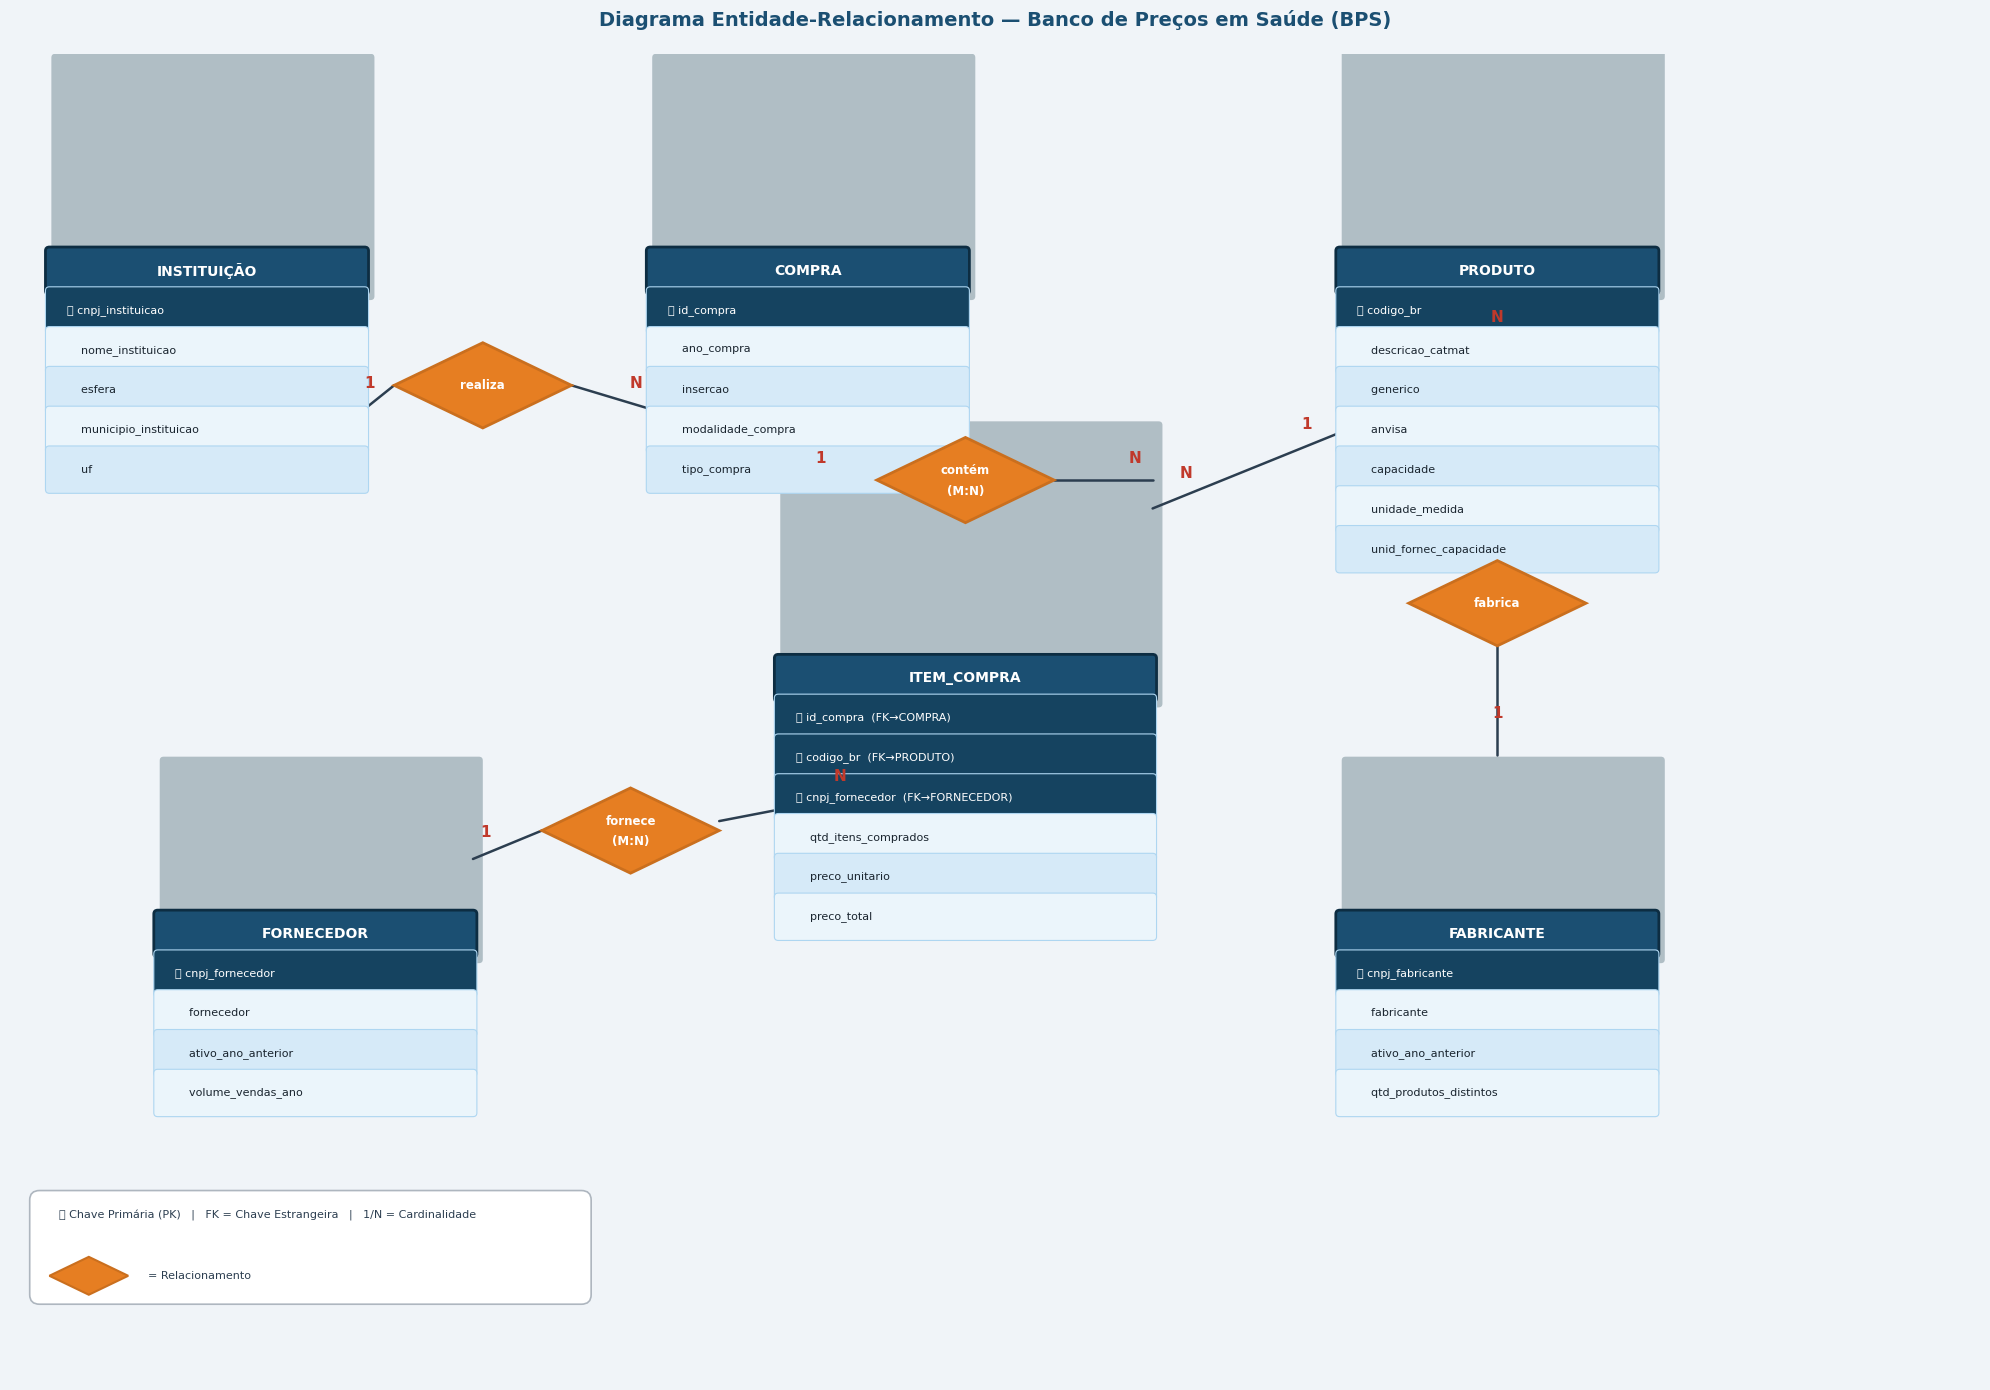

✅ Diagrama ER salvo em diagrams/diagrama_er.png


In [9]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

os.makedirs('diagrams', exist_ok=True)

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')
fig.patch.set_facecolor('#F0F4F8')
ax.set_facecolor('#F0F4F8')

# ── Cores ──────────────────────────────────────────────────
COR_HEADER    = '#1B4F72'
COR_ATTR_PAR  = '#D6EAF8'
COR_ATTR_IMP  = '#EBF5FB'
COR_PK_BG     = '#154360'
COR_DIAMOND   = '#E67E22'
COR_LINE      = '#2C3E50'
COR_CARD      = '#C0392B'

def draw_entity(ax, x, y, title, attrs, width=3.2):
    row_h = 0.42
    # Sombra
    ax.add_patch(FancyBboxPatch((x+0.06, y-0.06),
                  width, row_h * (len(attrs) + 1),
                  boxstyle="round,pad=0.04",
                  fc='#B0BEC5', ec='none', zorder=1))
    # Cabeçalho
    ax.add_patch(FancyBboxPatch((x, y), width, row_h,
                  boxstyle="round,pad=0.04",
                  fc=COR_HEADER, ec='#0D2D42', lw=2, zorder=2))
    ax.text(x + width/2, y + row_h/2, title,
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='white', zorder=3)
    # Atributos
    for i, (attr, is_pk) in enumerate(attrs):
        bg = COR_PK_BG if is_pk else (COR_ATTR_PAR if i % 2 == 0 else COR_ATTR_IMP)
        fc_text = 'white' if is_pk else '#1A252F'
        ax.add_patch(FancyBboxPatch((x, y - (i+1)*row_h), width, row_h,
                      boxstyle="round,pad=0.04",
                      fc=bg, ec='#AED6F1', lw=0.8, zorder=2))
        prefix = '🔑 ' if is_pk else '    '
        ax.text(x + 0.18, y - (i+1)*row_h + row_h/2,
                prefix + attr,
                ha='left', va='center',
                fontsize=8, color=fc_text, zorder=3)

def draw_diamond(ax, cx, cy, label, size_x=0.9, size_y=0.45):
    diamond = plt.Polygon(
        [[cx, cy+size_y], [cx+size_x, cy],
         [cx, cy-size_y], [cx-size_x, cy]],
        fc=COR_DIAMOND, ec='#CA6F1E', lw=2, zorder=4)
    ax.add_patch(diamond)
    for line in label.split('\n'):
        offset = 0.1 if '\n' in label else 0
        ax.text(cx, cy + offset - label.split('\n').index(line)*0.22,
                line, ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                color='white', zorder=5)

def draw_conn(ax, x1, y1, x2, y2, card1='', card2=''):
    ax.plot([x1, x2], [y1, y2],
            color=COR_LINE, lw=1.8,
            solid_capstyle='round', zorder=1)
    # Cardinalidades
    if card1:
        dx, dy = x2-x1, y2-y1
        ax.text(x1 + dx*0.18, y1 + dy*0.18 + 0.18,
                card1, ha='center', fontsize=11,
                fontweight='bold', color=COR_CARD, zorder=6)
    if card2:
        dx, dy = x2-x1, y2-y1
        ax.text(x1 + dx*0.82, y1 + dy*0.82 + 0.18,
                card2, ha='center', fontsize=11,
                fontweight='bold', color=COR_CARD, zorder=6)

# ══════════════════════════════════════════════
# ENTIDADES
# Posicionamento: layout em cruz com ITEM_COMPRA no centro
# ══════════════════════════════════════════════

# INSTITUIÇÃO — esquerda
draw_entity(ax, 0.4, 11.5, 'INSTITUIÇÃO', [
    ('cnpj_instituicao', True),
    ('nome_instituicao', False),
    ('esfera', False),
    ('municipio_instituicao', False),
    ('uf', False),
])

# COMPRA — centro-topo
draw_entity(ax, 6.5, 11.5, 'COMPRA', [
    ('id_compra', True),
    ('ano_compra', False),
    ('insercao', False),
    ('modalidade_compra', False),
    ('tipo_compra', False),
])

# PRODUTO — direita
draw_entity(ax, 13.5, 11.5, 'PRODUTO', [
    ('codigo_br', True),
    ('descricao_catmat', False),
    ('generico', False),
    ('anvisa', False),
    ('capacidade', False),
    ('unidade_medida', False),
    ('unid_fornec_capacidade', False),
])

# ITEM_COMPRA — centro
draw_entity(ax, 7.8, 7.2, 'ITEM_COMPRA', [
    ('id_compra  (FK→COMPRA)', True),
    ('codigo_br  (FK→PRODUTO)', True),
    ('cnpj_fornecedor  (FK→FORNECEDOR)', True),
    ('qtd_itens_comprados', False),
    ('preco_unitario', False),
    ('preco_total', False),
], width=3.8)

# FORNECEDOR — esquerda-baixo
draw_entity(ax, 1.5, 4.5, 'FORNECEDOR', [
    ('cnpj_fornecedor', True),
    ('fornecedor', False),
    ('ativo_ano_anterior', False),
    ('volume_vendas_ano', False),
])

# FABRICANTE — direita-baixo
draw_entity(ax, 13.5, 4.5, 'FABRICANTE', [
    ('cnpj_fabricante', True),
    ('fabricante', False),
    ('ativo_ano_anterior', False),
    ('qtd_produtos_distintos', False),
])

# ══════════════════════════════════════════════
# LOSANGOS DE RELACIONAMENTO
# ══════════════════════════════════════════════
draw_diamond(ax, 4.8,  10.5, 'realiza')        # INSTITUIÇÃO – COMPRA
draw_diamond(ax, 9.7,   9.5, 'contém\n(M:N)')  # COMPRA – ITEM_COMPRA – PRODUTO
draw_diamond(ax, 6.3,   5.8, 'fornece\n(M:N)') # ITEM_COMPRA – FORNECEDOR
draw_diamond(ax, 15.1,  8.2, 'fabrica')        # FABRICANTE – PRODUTO

# ══════════════════════════════════════════════
# CONEXÕES
# ══════════════════════════════════════════════

# INSTITUIÇÃO → realiza
draw_conn(ax, 3.6, 10.25, 4.8-0.9, 10.5,  card1='1')
# realiza → COMPRA
draw_conn(ax, 4.8+0.9, 10.5, 6.5, 10.25,  card2='N')

# COMPRA → contém
draw_conn(ax, 8.1, 9.5, 9.7-0.9, 9.5,     card1='1')
# contém → ITEM_COMPRA
draw_conn(ax, 9.7+0.9, 9.5, 11.6, 9.5,    card2='N')
# ITEM_COMPRA (direita) → PRODUTO
draw_conn(ax, 11.6, 9.2, 13.5, 10.0,      card1='N', card2='1')

# ITEM_COMPRA → fornece
draw_conn(ax, 8.7, 6.2, 6.3+0.9, 5.9,     card1='N')
# fornece → FORNECEDOR
draw_conn(ax, 6.3-0.9, 5.8, 4.7, 5.5,     card2='1')

# FABRICANTE → fabrica
draw_conn(ax, 15.1, 6.6, 15.1, 8.2-0.45,  card1='1')
# fabrica → PRODUTO
draw_conn(ax, 15.1, 8.2+0.45, 15.1, 11.5, card2='N')

# ══════════════════════════════════════════════
# LEGENDA
# ══════════════════════════════════════════════
legend_x, legend_y = 0.3, 1.2
ax.add_patch(FancyBboxPatch((legend_x, legend_y-0.3), 5.5, 1.0,
              boxstyle="round,pad=0.1",
              fc='white', ec='#AEB6BF', lw=1.2, zorder=2))
ax.text(legend_x+0.2, legend_y+0.5,
        '🔑 Chave Primária (PK)   |   FK = Chave Estrangeira   |   '
        '1/N = Cardinalidade',
        fontsize=8, color='#2C3E50', zorder=3)
ax.add_patch(plt.Polygon(
    [[legend_x+0.5, legend_y+0.1],
     [legend_x+0.9, legend_y-0.1],
     [legend_x+0.5, legend_y-0.3],
     [legend_x+0.1, legend_y-0.1]],
    fc=COR_DIAMOND, ec='#CA6F1E', lw=1.5, zorder=3))
ax.text(legend_x+1.1, legend_y-0.1,
        '= Relacionamento', fontsize=8, color='#2C3E50',
        va='center', zorder=3)

plt.title('Diagrama Entidade-Relacionamento — Banco de Preços em Saúde (BPS)',
          fontsize=14, fontweight='bold', pad=20, color=COR_HEADER)
plt.tight_layout()
plt.savefig('diagrams/diagrama_er.png', dpi=180, bbox_inches='tight')
plt.show()
print("✅ Diagrama ER salvo em diagrams/diagrama_er.png")

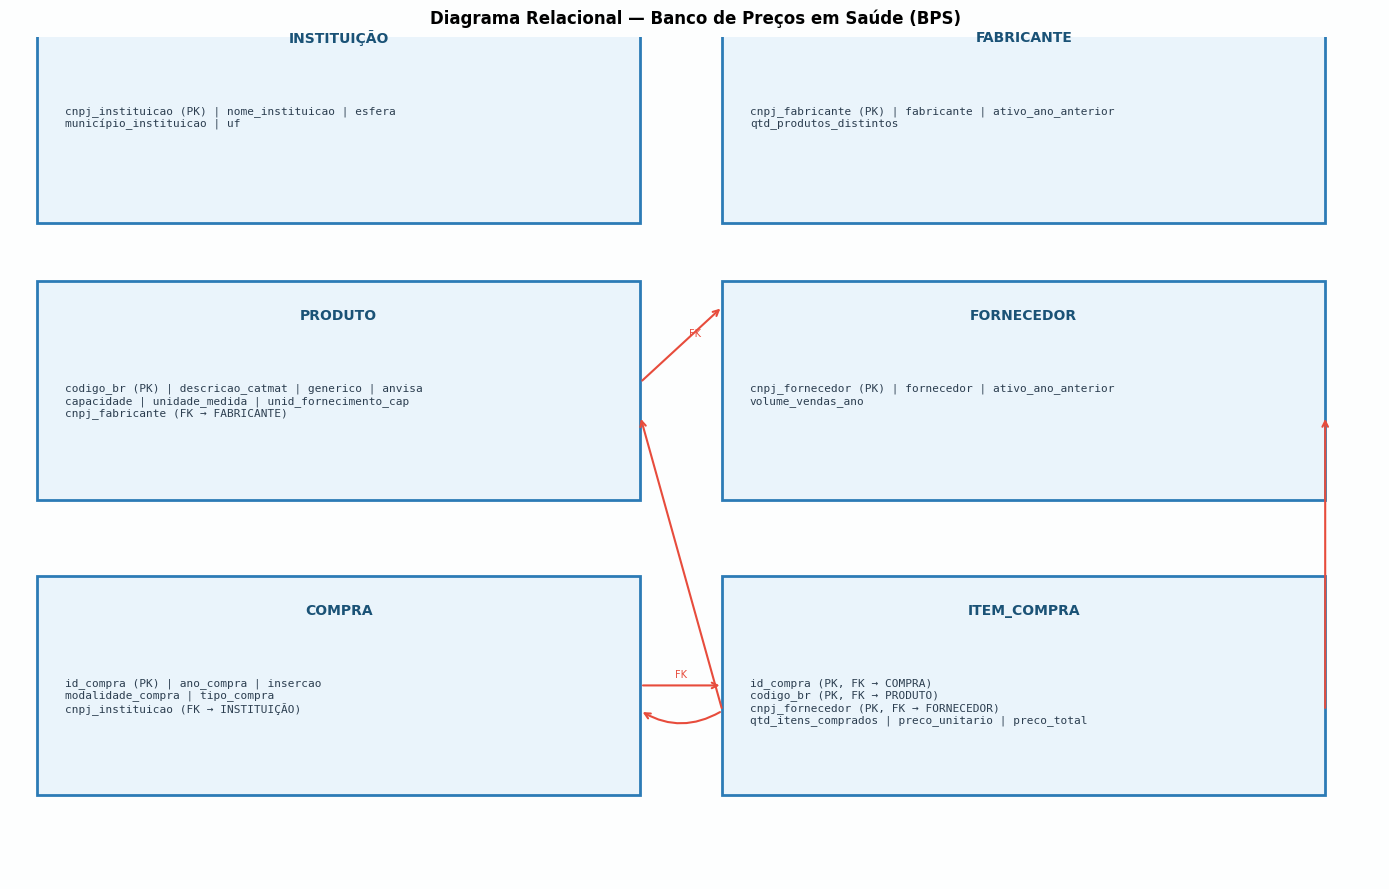

✅ Diagrama Relacional salvo em diagrams/diagrama_relacional.png


In [10]:
# Seção 5 — Diagrama Relacional
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 9))
ax.axis('off')
fig.patch.set_facecolor('#fdfefe')

schemas = [
    ("INSTITUIÇÃO",
     "cnpj_instituicao (PK) | nome_instituicao | esfera\nmunicípio_instituicao | uf"),

    ("FABRICANTE",
     "cnpj_fabricante (PK) | fabricante | ativo_ano_anterior\nqtd_produtos_distintos"),

    ("PRODUTO",
     "codigo_br (PK) | descricao_catmat | generico | anvisa\ncapacidade | unidade_medida | unid_fornecimento_cap\ncnpj_fabricante (FK → FABRICANTE)"),

    ("FORNECEDOR",
     "cnpj_fornecedor (PK) | fornecedor | ativo_ano_anterior\nvolume_vendas_ano"),

    ("COMPRA",
     "id_compra (PK) | ano_compra | insercao\nmodalidade_compra | tipo_compra\ncnpj_instituicao (FK → INSTITUIÇÃO)"),

    ("ITEM_COMPRA",
     "id_compra (PK, FK → COMPRA)\ncodigo_br (PK, FK → PRODUTO)\ncnpj_fornecedor (PK, FK → FORNECEDOR)\nqtd_itens_comprados | preco_unitario | preco_total"),
]

positions = [(0.02, 0.78), (0.52, 0.78),
             (0.02, 0.45), (0.52, 0.45),
             (0.02, 0.10), (0.52, 0.10)]

for (title, schema), (px, py) in zip(schemas, positions):
    ax.add_patch(plt.Rectangle((px, py), 0.44, 0.26,
                 transform=ax.transAxes, fc='#eaf4fb', ec='#2c7bb6', lw=2))
    ax.text(px + 0.22, py + 0.22, title,
            transform=ax.transAxes, ha='center', va='center',
            fontsize=10, fontweight='bold', color='#1a5276')
    ax.text(px + 0.02, py + 0.14, schema,
            transform=ax.transAxes, ha='left', va='top',
            fontsize=8, color='#2c3e50', family='monospace')

# Setas de FK
arrow_props = dict(arrowstyle='->', color='#e74c3c', lw=1.5,
                   connectionstyle='arc3,rad=0.0')

# COMPRA → INSTITUIÇÃO
ax.annotate('', xy=(0.52, 0.23), xytext=(0.46, 0.23),
            xycoords='axes fraction', arrowprops=arrow_props)
ax.text(0.49, 0.24, 'FK', transform=ax.transAxes,
        ha='center', fontsize=7, color='#e74c3c')

# PRODUTO → FABRICANTE
ax.annotate('', xy=(0.52, 0.68), xytext=(0.46, 0.59),
            xycoords='axes fraction', arrowprops=arrow_props)
ax.text(0.50, 0.645, 'FK', transform=ax.transAxes,
        ha='center', fontsize=7, color='#e74c3c')

# ITEM_COMPRA → COMPRA
ax.annotate('', xy=(0.46, 0.20), xytext=(0.52, 0.20),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5,
                            connectionstyle='arc3,rad=-0.3'))

# ITEM_COMPRA → PRODUTO
ax.annotate('', xy=(0.46, 0.55), xytext=(0.52, 0.20),
            xycoords='axes fraction', arrowprops=arrow_props)

# ITEM_COMPRA → FORNECEDOR
ax.annotate('', xy=(0.96, 0.55), xytext=(0.96, 0.20),
            xycoords='axes fraction', arrowprops=arrow_props)

plt.title('Diagrama Relacional — Banco de Preços em Saúde (BPS)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('diagrams/diagrama_relacional.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diagrama Relacional salvo em diagrams/diagrama_relacional.png")

## Consulta 1 — Produtos Genéricos Disponíveis

Esta consulta seleciona todos os produtos classificados como genéricos
no catálogo do BPS, exibindo código, descrição e unidade de medida.
O objetivo é identificar quais itens possuem versão genérica disponível
no sistema de compras públicas de saúde.

In [18]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('trabalho_pratico_2.db')

query1 = """
SELECT codigo_br,
       descricao_catmat,
       unidade_medida
FROM Produto
WHERE generico = 'Sim'
ORDER BY descricao_catmat
LIMIT 20;
"""
df1 = pd.read_sql_query(query1, conn)
display(df1)

,codigo_br,descricao_catmat,unidade_medida


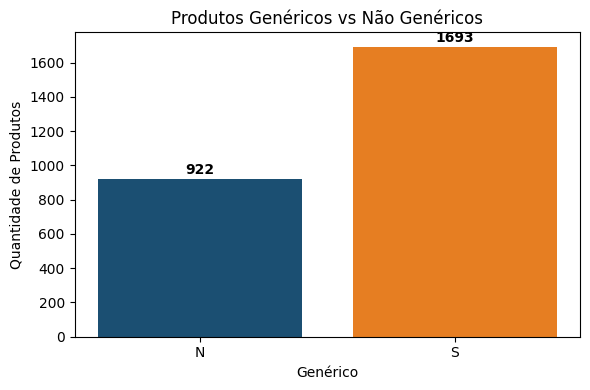

In [19]:
contagem = pd.read_sql_query("""
    SELECT generico, COUNT(*) as total
    FROM Produto
    WHERE generico IS NOT NULL
    GROUP BY generico
""", conn)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(contagem['generico'], contagem['total'],
       color=['#1B4F72','#E67E22'])
ax.set_title('Produtos Genéricos vs Não Genéricos')
ax.set_xlabel('Genérico')
ax.set_ylabel('Quantidade de Produtos')
for i, v in enumerate(contagem['total']):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/consulta1.png', dpi=120)
plt.show()

## Consulta 2 — Distribuição de Instituições por Estado e Esfera

Esta consulta agrupa as instituições compradoras por UF e esfera
administrativa (municipal, estadual, federal), permitindo visualizar
como o poder de compra está distribuído geograficamente no Brasil.

In [20]:
query2 = """
SELECT uf,
       esfera,
       COUNT(*) as total_instituicoes
FROM Instituicao
GROUP BY uf, esfera
ORDER BY total_instituicoes DESC
LIMIT 20;
"""
df2 = pd.read_sql_query(query2, conn)
display(df2)

,uf,esfera,total_instituicoes
0,PR,MUNICIPAL,159
1,SP,MUNICIPAL,107
2,PB,MUNICIPAL,71
3,RO,MUNICIPAL,67
4,PI,MUNICIPAL,65
5,RS,MUNICIPAL,46
6,PE,MUNICIPAL,40
7,AL,MUNICIPAL,31
8,ES,MUNICIPAL,31
9,MG,MUNICIPAL,28


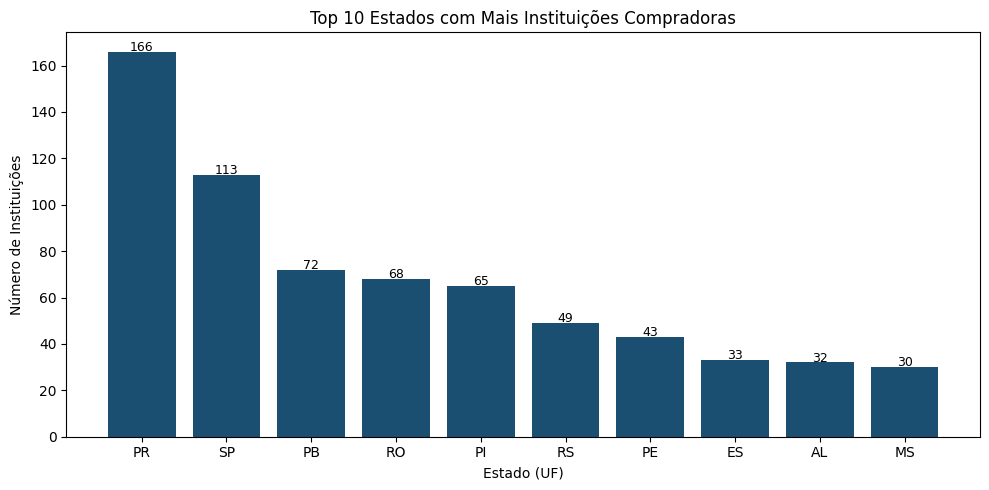

In [21]:
top_uf = pd.read_sql_query("""
    SELECT uf, COUNT(*) as total
    FROM Instituicao
    GROUP BY uf
    ORDER BY total DESC
    LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(top_uf['uf'], top_uf['total'], color='#1B4F72')
ax.set_title('Top 10 Estados com Mais Instituições Compradoras')
ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Número de Instituições')
for bar, val in zip(bars, top_uf['total']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('diagrams/consulta2.png', dpi=120)
plt.show()

## Consulta 3 — Compras Realizadas por Instituição

Esta consulta junta as tabelas Compra e Instituição para mostrar
quantas compras cada instituição realizou ao longo do tempo,
identificando os maiores compradores do sistema público de saúde.

In [22]:
query3 = """
SELECT I.nome_instituicao,
       I.uf,
       I.esfera,
       COUNT(C.id_compra) as total_compras
FROM Instituicao I
JOIN Compra C ON I.cnpj_instituicao = C.cnpj_instituicao
GROUP BY I.cnpj_instituicao
ORDER BY total_compras DESC
LIMIT 15;
"""
df3 = pd.read_sql_query(query3, conn)
display(df3)

,nome_instituicao,uf,esfera,total_compras
0,MUNICIPIO DE ELDORADO DO SUL,RS,MUNICIPAL,258
1,MUNICIPIO DE ESTEIO,RS,MUNICIPAL,109
2,SECRETARIA DE ESTADO DA SAUDE,SP,ESTADUAL,93
3,MUNICIPIO DE CAXIAS DO SUL,RS,MUNICIPAL,82
4,SECRETARIA DE ESTADO DA SAUDE,PR,ESTADUAL,79
5,SECRETARIA DA SAUDE,RS,ESTADUAL,66
6,SECRETARIA DE ESTADO DE SAUDE - SES,RJ,ESTADUAL,63
7,FUNDO MUNICIPAL DE SAUDE,PR,MUNICIPAL,52
8,SECRETARIA DE ESTADO DA SAUDE - SES,PB,ESTADUAL,51
9,MUNICIPIO DE FLORES DA CUNHA,RS,MUNICIPAL,41


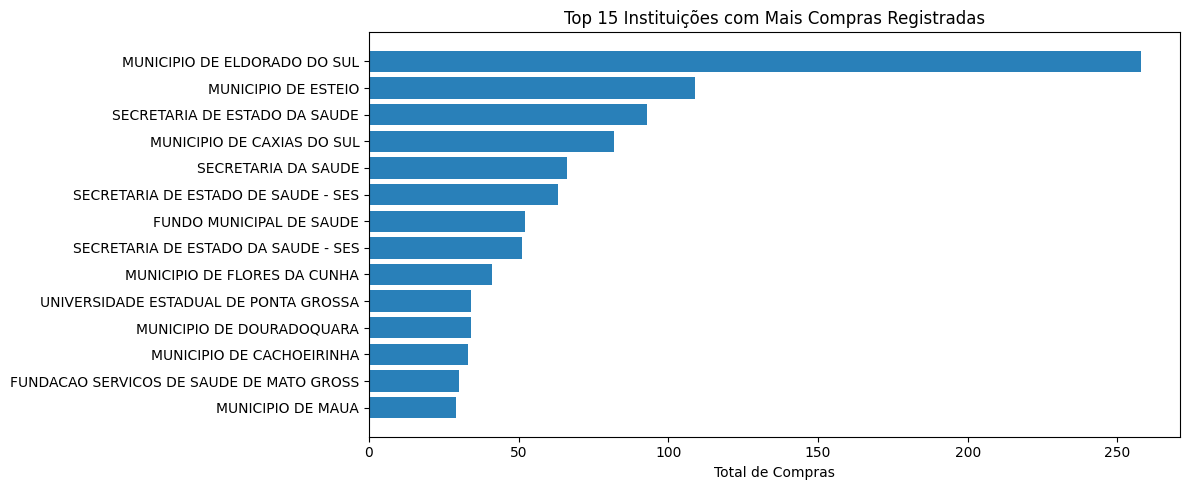

In [23]:
fig, ax = plt.subplots(figsize=(12,5))
ax.barh(df3['nome_instituicao'].str[:40],
        df3['total_compras'], color='#2980B9')
ax.set_title('Top 15 Instituições com Mais Compras Registradas')
ax.set_xlabel('Total de Compras')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('diagrams/consulta3.png', dpi=120)
plt.show()

## Consulta 4 — Produtos por Fabricante

Esta consulta junta Produto e Fabricante para listar quais fabricantes
possuem mais produtos distintos registrados no catálogo, indicando
os maiores players do mercado de saúde pública brasileira.

In [24]:
query4 = """
SELECT F.fabricante,
       COUNT(P.codigo_br) as qtd_produtos
FROM Fabricante F
JOIN Produto P ON F.cnpj_fabricante = P.cnpj_fabricante
GROUP BY F.cnpj_fabricante
ORDER BY qtd_produtos DESC
LIMIT 15;
"""
df4 = pd.read_sql_query(query4, conn)
display(df4)

,fabricante,qtd_produtos
0,"PRATI, DONADUZZI & CIA LTDA",439
1,CIRURGICA FERNANDES - COMERCIO DE MATERIAIS CI...,292
2,ABC INSTRUMENTOS CIRURGICOS LTDA,244
3,JOAOMED COMERCIO DE MATERIAIS CIRURGICOS S/A,207
4,EUROFARMA LABORATORIOS S.A.,197
5,SHALON FIOS CIRURGICOS LTDA,194
6,BIOLINE FIOS CIRURGICOS LTDA,190
7,MEDIX DISTRIBUICAO COMERCIO E REPRESENTACAO LTDA,179
8,BIODINAMICA QUIMICA E FARMACEUTICA LTDA,168
9,PRATA HOSPITALAR LTDA,153


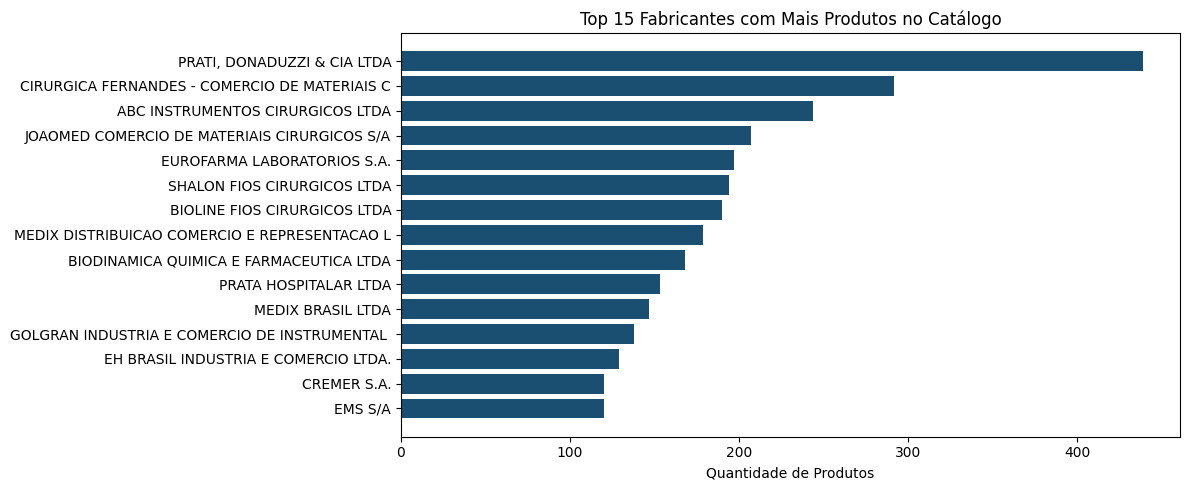

In [25]:
fig, ax = plt.subplots(figsize=(12,5))
ax.barh(df4['fabricante'].str[:45],
        df4['qtd_produtos'], color='#1B4F72')
ax.set_title('Top 15 Fabricantes com Mais Produtos no Catálogo')
ax.set_xlabel('Quantidade de Produtos')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('diagrams/consulta4.png', dpi=120)
plt.show()

## Consulta 5 — Volume de Vendas por Fornecedor

Esta consulta junta Fornecedor e Item_Compra para calcular o
faturamento total e o número de pedidos de cada fornecedor,
revelando quais empresas dominam o mercado de fornecimento
de produtos médico-hospitalares para o setor público.

In [26]:
query5 = """
SELECT F.fornecedor,
       COUNT(IC.id_compra)    as total_pedidos,
       SUM(IC.preco_total)    as faturamento_total,
       AVG(IC.preco_unitario) as preco_medio_unitario
FROM Fornecedor F
JOIN Item_Compra IC ON F.cnpj_fornecedor = IC.cnpj_fornecedor
GROUP BY F.cnpj_fornecedor
ORDER BY faturamento_total DESC
LIMIT 15;
"""
df5 = pd.read_sql_query(query5, conn)
df5['faturamento_total'] = df5['faturamento_total'].round(2)
display(df5)

,fornecedor,total_pedidos,faturamento_total,preco_medio_unitario
0,AGILLE COMERCIO DE MEDICAMENTOS LTDA,17,2.284557e+10,17455.518235
1,SP HOSPITALAR LTDA,158,3.825198e+09,1382.814853
2,ASTRAZENECA DO BRASIL LTDA.,188,3.433728e+09,49689.089940
3,JANSSEN-CILAG FARMACEUTICA LTDA,210,1.824699e+09,4172.043131
4,NOVARTIS BIOCIENCIAS SA,232,1.767295e+09,9197.363745
5,ONCOVIT DISTRIBUIDORA DE MEDICAMENTOS LTDA,502,1.674101e+09,10940.655784
6,ATIVA COMERCIAL HOSPITALAR LTDA,413,1.024845e+09,69.988994
7,CRISTALIA PRODUTOS QUIMICOS FARMACEUTICOS LTDA,5919,9.847246e+08,11.024779
8,ELFA MEDICAMENTOS S.A,307,9.831081e+08,1503.982394
9,ONCO PROD DISTRIBUIDORA DE PRODUTOS HOSPITALAR...,374,9.230399e+08,2974.949114


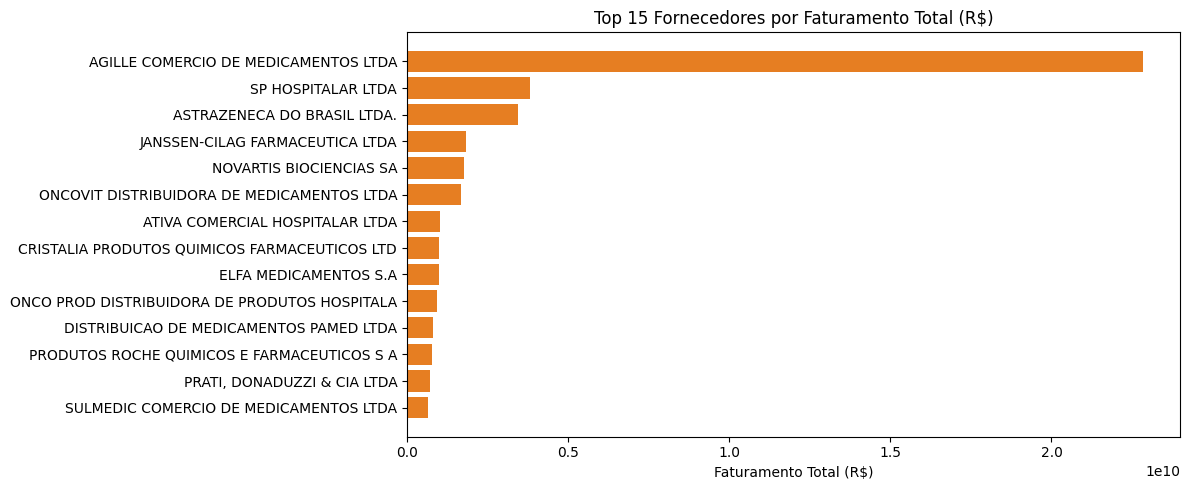

In [27]:
fig, ax = plt.subplots(figsize=(12,5))
ax.barh(df5['fornecedor'].str[:45],
        df5['faturamento_total'], color='#E67E22')
ax.set_title('Top 15 Fornecedores por Faturamento Total (R$)')
ax.set_xlabel('Faturamento Total (R$)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('diagrams/consulta5.png', dpi=120)
plt.show()

## Consulta 6 — Compras por Instituição, Produto e Fabricante

Esta consulta junta 4 tabelas para rastrear o caminho completo
de uma compra: qual instituição comprou, qual produto e de qual
fabricante. Permite auditar o processo de compra pública e
identificar os maiores gastos por combinação instituição-produto.

In [28]:
query6 = """
SELECT I.nome_instituicao,
       I.uf,
       P.descricao_catmat,
       F.fabricante,
       SUM(IC.qtd_itens_comprados) as qtd_total,
       ROUND(SUM(IC.preco_total), 2) as gasto_total
FROM Item_Compra IC
JOIN Compra      C ON IC.id_compra       = C.id_compra
JOIN Instituicao I ON C.cnpj_instituicao = I.cnpj_instituicao
JOIN Produto     P ON IC.codigo_br       = P.codigo_br
JOIN Fabricante  F ON P.cnpj_fabricante  = F.cnpj_fabricante
GROUP BY I.cnpj_instituicao, P.codigo_br, F.cnpj_fabricante
ORDER BY gasto_total DESC
LIMIT 15;
"""
df6 = pd.read_sql_query(query6, conn)
display(df6)

,nome_instituicao,uf,descricao_catmat,fabricante,qtd_total,gasto_total
0,MUNICIPIO DE PORTO ALEGRE,RS,"PENICILAMINA, DOSAGEM:250 MG",UCB BIOPHARMA LTDA.,77500,2.281600e+10
1,SECRETARIA DE ESTADO DA SAUDE,PR,"ÁCIDO ZOLEDRÔNICO, CONCENTRAÇÃO:50 MCG/ML, FOR...",LIBBS FARMACEUTICA LTDA,20064,3.713165e+09
2,MUNICIPIO DE CAXIAS DO SUL,RS,"TEZEPELUMABE, CONCENTRAÇÃO:110 MG/ML, FORMA FA...",ASTRAZENECA DO BRASIL LTDA.,216,1.663020e+09
3,SECRETARIA DE ESTADO DE SAUDE - SES,RJ,"CARFILZOMIB, CONCENTRAÇÃO:60 MG, FORMA FARMACE...",AMGEN BIOTECNOLOGIA DO BRASIL LTDA.,284,1.364418e+09
4,MUNICIPIO DE BARUERI,SP,"BUDESONIDA, CONCENTRAÇÃO:50 MCG/DOSE, FORMA FA...",MULTILAB INDUSTRIA E COMERCIO DE PRODUTOS FARM...,15241500,9.608863e+08
5,MUNICIPIO DE ESTEIO,RS,"AXITINIBE, CONCENTRAÇÃO:5 MG",PFIZER BRASIL LTDA,2820,7.137138e+08
6,MUNICIPIO DE ELDORADO DO SUL,RS,"NUSINERSENA, CONCENTRAÇÃO:2,4 MG/ML, FORMA FAR...",BIOGEN BRASIL PRODUTOS FARMACEUTICOS LTDA,2278,6.770362e+08
7,FUNDO MUNICIPAL DE SAUDE,PR,"COMPRESSA GAZE, MATERIAL:TECIDO 100% ALGODÃO, ...",CREMER S.A.,4465000,6.221486e+08
8,SECRETARIA DE ESTADO DA SAUDE,PR,"USTEQUINUMABE, CONCENTRAÇÃO:90 MG/ML, FORMA FA...",JANSSEN-CILAG FARMACEUTICA LTDA,23236,5.585028e+08
9,SECRETARIA DE ESTADO DA SAUDE,SP,"CALCIPOTRIOL, DOSAGEM:50 MCG/G, USO:POMADA",PRODUTOS ROCHE QUIMICOS E FARMACEUTICOS S A,620880000,5.277480e+08


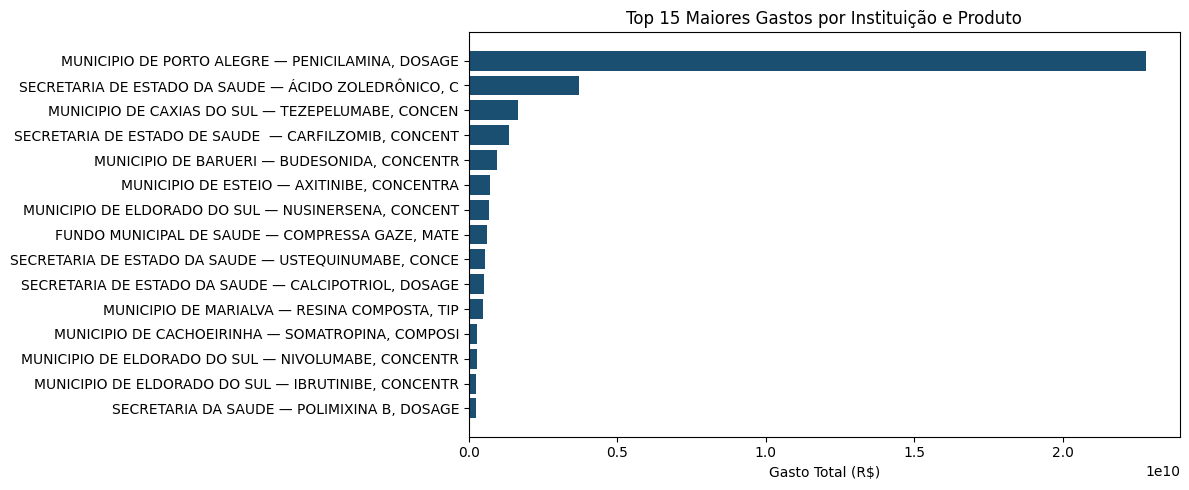

In [29]:
fig, ax = plt.subplots(figsize=(12,5))
labels = df6['nome_instituicao'].str[:30] + ' — ' + df6['descricao_catmat'].str[:20]
ax.barh(labels, df6['gasto_total'], color='#1B4F72')
ax.set_title('Top 15 Maiores Gastos por Instituição e Produto')
ax.set_xlabel('Gasto Total (R$)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('diagrams/consulta6.png', dpi=120)
plt.show()

## Consulta 7 — Preço Médio por Modalidade de Compra e UF

Esta consulta junta Item_Compra, Compra e Instituição para analisar
como a modalidade de licitação (Pregão, Dispensa, etc.) impacta o
preço médio pago por região, permitindo identificar padrões de
eficiência nas compras públicas de saúde por estado.

In [30]:
query7 = """
SELECT C.modalidade_compra,
       I.uf,
       COUNT(IC.id_compra)           as total_itens,
       ROUND(AVG(IC.preco_unitario), 2) as preco_medio,
       ROUND(SUM(IC.preco_total), 2)    as gasto_total
FROM Item_Compra IC
JOIN Compra      C ON IC.id_compra       = C.id_compra
JOIN Instituicao I ON C.cnpj_instituicao = I.cnpj_instituicao
GROUP BY C.modalidade_compra, I.uf
ORDER BY gasto_total DESC
LIMIT 20;
"""
df7 = pd.read_sql_query(query7, conn)
display(df7)

,modalidade_compra,uf,total_itens,preco_medio,gasto_total
0,Pregão,RS,107943,157.20,3.787702e+10
1,Registro de Preços,RS,28077,496.78,7.530008e+09
2,Registro de Preços,PR,12704,164.42,6.751410e+09
3,Pregão,PR,70116,73.91,5.690528e+09
4,Pregão,SP,22662,210.47,5.187343e+09
5,Tomada de Preços,RS,42567,68.69,4.539821e+09
6,Tomada de Preços,PR,21664,107.07,2.997498e+09
7,Registro de Preços,SP,6748,204.84,2.983312e+09
8,Registro de Preços,RJ,1589,3297.13,1.444746e+09
9,Tomada de Preços,SP,7797,62.02,8.180087e+08


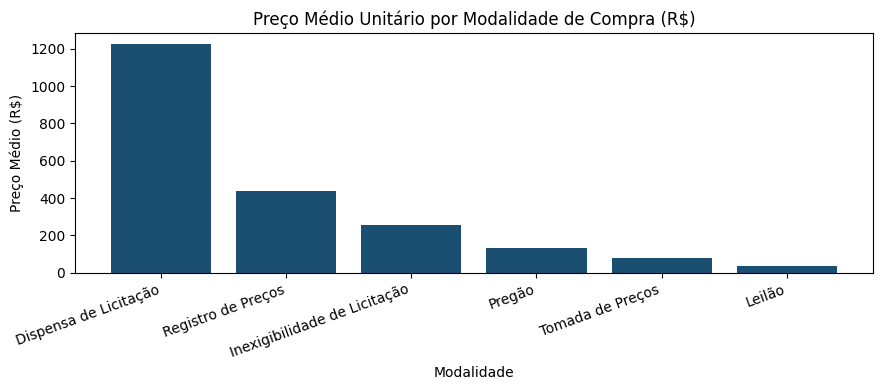

In [31]:
modal = pd.read_sql_query("""
    SELECT C.modalidade_compra,
           ROUND(AVG(IC.preco_unitario), 2) as preco_medio
    FROM Item_Compra IC
    JOIN Compra C ON IC.id_compra = C.id_compra
    GROUP BY C.modalidade_compra
    ORDER BY preco_medio DESC
""", conn)

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(modal['modalidade_compra'],
       modal['preco_medio'], color='#1B4F72')
ax.set_title('Preço Médio Unitário por Modalidade de Compra (R$)')
ax.set_xlabel('Modalidade')
ax.set_ylabel('Preço Médio (R$)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('diagrams/consulta7.png', dpi=120)
plt.show()